In [2]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
GDP_path = "/mnt/warehouse/shifting_cultivation/111_result/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv"

In [14]:
# Load GDP dataset
gdp_df = pd.read_csv(GDP_path, encoding="latin1")

In [15]:
sc = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/output_file/sc_with_cropland_gdp_capita.gpkg")

In [16]:
# Filter indicators
gdp_df = gdp_df[gdp_df["Indicator Name"].isin([
    "GDP per capita (current US$)"
])]

# Keep needed columns
gdp_df = gdp_df[[
    "Country Name",
    "Country Code",
    "Indicator Name",
    "2020"
]]

# Pivot with BOTH name and code
gdp_df = gdp_df.pivot(
    index=["Country Name", "Country Code"],
    columns="Indicator Name",
    values="2020"
).reset_index()

In [9]:
# import pycountry

# def get_iso3(name):
#     try:
#         return pycountry.countries.lookup(name).alpha_3
#     except:
#         return None

# sc["Country Code"] = sc["country"].apply(get_iso3)

In [17]:
sc_gdp = sc.merge(gdp_df, on="Country Code", how="left")

In [22]:
sc_gdp.to_file('/mnt/warehouse/shifting_cultivation/111_result/output_file/sc_with_cropland_gdp_capita_1.gpkg')

In [3]:
sc_gdp= gpd.read_file('/mnt/warehouse/shifting_cultivation/111_result/output_file/sc_with_cropland_gdp_capita_1.gpkg')

In [4]:
print(sc_gdp.columns.tolist())

['Unnamed: 0', 'field_1', 'country', 'class_0_km2', 'class_1_km2', 'class_2_km2', 'class_3_km2', 'class_4_km2', 'country_area_km2', 'pred_area_km2', 'coverage_pct', 'prediction_status', 'sc_ci_km2', 'sc_ci_Mha', 'sc_Mha', 'continent', 'cropland_area', 'Country Code', 'cropland_km2', 'Country Name_y', 'Agriculture, forestry, and fishing, value added (% of GDP)_y', 'GDP (current US$)_y', 'GDP per person employed (constant 2021 PPP $)_y', 'Country Name', 'GDP per capita (current US$)', 'geometry']


In [5]:
import pandas as pd
import numpy as np

df_1 = sc_gdp.copy()

cols = ["class_1_km2", "country_area_km2", "cropland_area", "GDP per capita (current US$)"]

for c in cols:
    df_1[c] = pd.to_numeric(df_1[c], errors="coerce")

# km² → kha
df_1["sc_kha"] = df_1["class_1_km2"] * 0.1

# remove bad rows
df_1 = df_1.dropna(subset=["sc_kha", "cropland_area", "GDP per capita (current US$)", "continent"])
df_1 = df_1[df_1["GDP per capita (current US$)"] > 0]

In [6]:
df_1["gdp_per_capita"] = df_1["GDP per capita (current US$)"]

size_min, size_max = 40, 900
df_1["bubble_size"] = size_min + (
    (df_1["gdp_per_capita"] - df_1["gdp_per_capita"].min()) /
    (df_1["gdp_per_capita"].max() - df_1["gdp_per_capita"].min())
) * (size_max - size_min)

In [7]:
df_1["sc_percentage"] = df_1["class_1_km2"] / df_1["country_area_km2"] * 100
df_1["cropland_percentage"] = (df_1["cropland_area"] * 10)/ df_1["country_area_km2"]* 100

In [8]:
df_1["sc_c_ratio"] = df_1["sc_kha"] / df_1["cropland_area"]

In [9]:
df_1_ratio = df_1[df_1["sc_c_ratio"] >= 1].copy()

print("Number of countries:", len(df_1_ratio))

Number of countries: 37


In [10]:
df_1["continent"] = df_1["continent"].replace({
    "Aisa-Oceania": "Asia-Oceania"
})

In [11]:
# Define consistent colors for each continent
continent_colors = {"Africa": "skyblue", "America": "orange", "Asia-Oceania": "green"}

In [12]:
# Sort by percentage
df_1 = df_1.sort_values(by="class_1_km2", ascending=False)

In [38]:
df_1.to_file('/mnt/warehouse/shifting_cultivation/111_result/output_file/GDP/sc_with_cropland_percentage_with_gdp_0323.gpkg')

In [13]:
df_1["GDP per capita (current US$)"].describe()

count       76.000000
mean      3726.497682
std       4247.474320
min        255.832454
25%        952.843287
50%       2187.592082
75%       4876.179358
max      26834.359223
Name: GDP per capita (current US$), dtype: float64

In [14]:
print(df_1["continent"].unique())

['Africa' 'America' 'Asia-Oceania']


In [16]:
df_1_ratio[["sc_c_ratio", "Agriculture, forestry, and fishing, value added (% of GDP)_y"]].corr(method="spearman")

,sc_c_ratio
sc_c_ratio,1.0


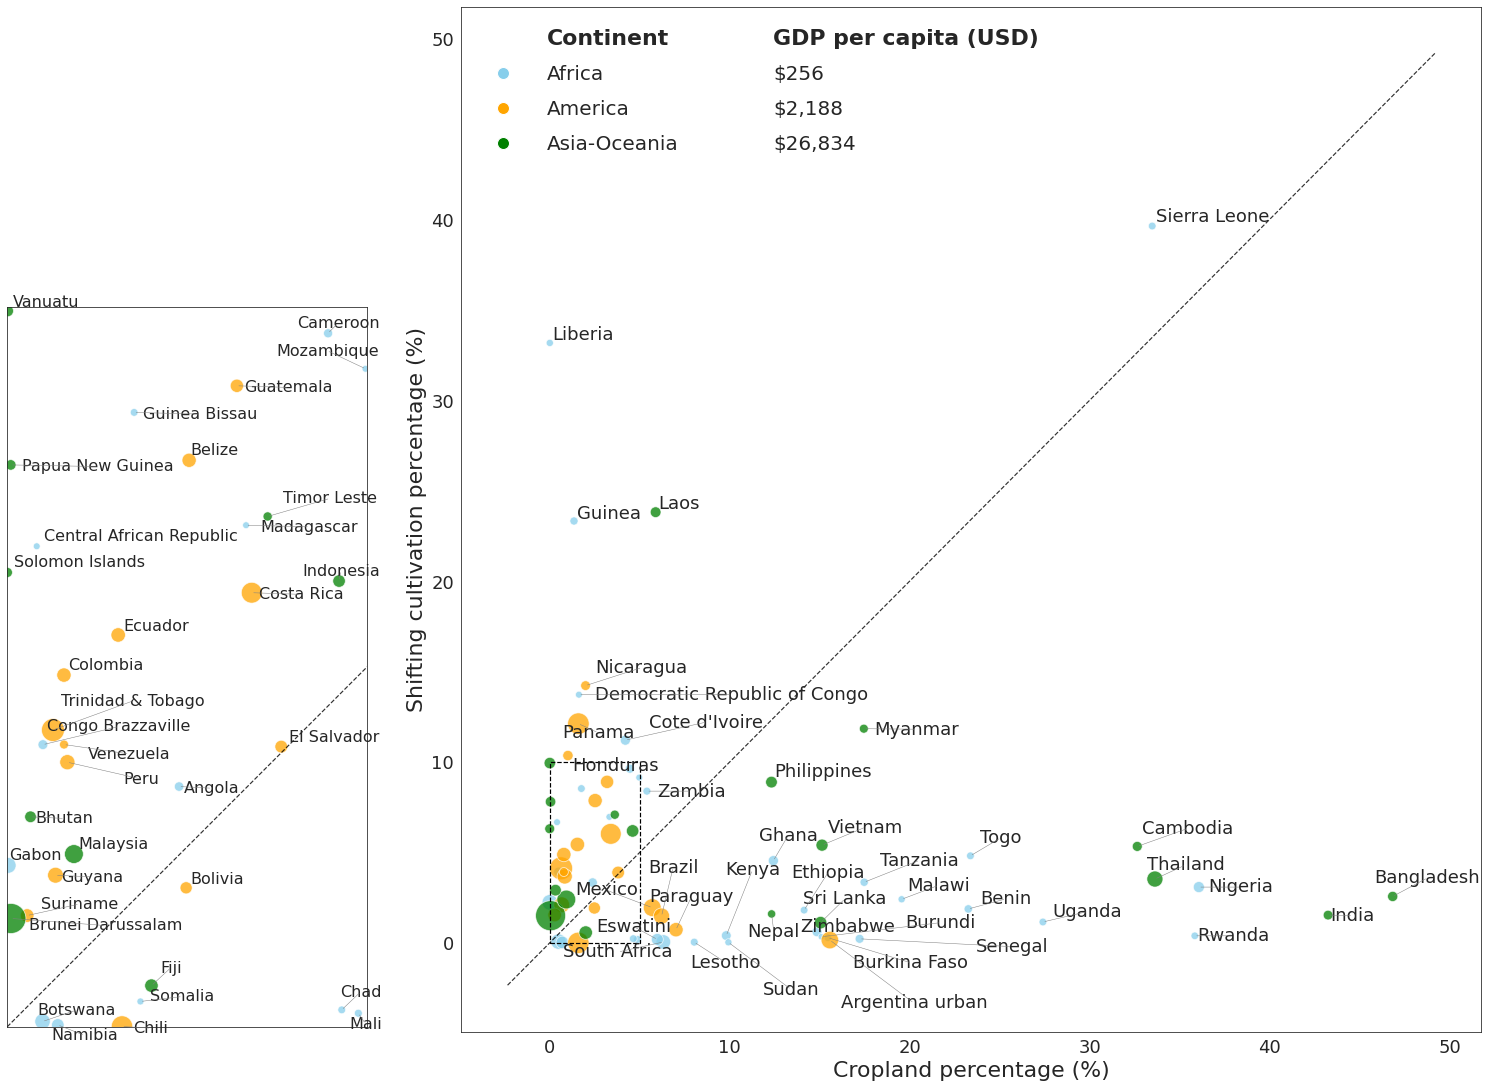

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from adjustText import adjust_text
import pandas as pd
from matplotlib.lines import Line2D

# --------------------------
# SETTINGS
# --------------------------

size_scale = 1

zoom_xmin, zoom_xmax = 0, 5
zoom_ymin, zoom_ymax = 0, 10

# Adjust inset location and size (can tune)
inset_x = -0.45
inset_y = 0
inset_width = 5
inset_height = 10

continent_colors = {
    "Africa": "skyblue",
    "America": "orange",
    "Asia-Oceania": "green"
}

# --------------------------
# PREPARE ZOOM CONDITION
# --------------------------

df_1["is_zoom"] = (
    (df_1["cropland_percentage"] <= zoom_xmax) &
    (df_1["sc_percentage"] <= zoom_ymax)
)

# --------------------------
# CREATE FIGURE
# --------------------------

fig, ax = plt.subplots(figsize=(15, 15), constrained_layout=True)

# --------------------------
# MAIN SCATTER
# --------------------------

texts_main = []

for cont, sub in df_1.groupby("continent"):
    sub = sub.sort_values("bubble_size", ascending=False)

    ax.scatter(
        sub["cropland_percentage"],
        sub["sc_percentage"],
        s=sub["bubble_size"] * size_scale,
        alpha=0.75,
        label=cont,
        color=continent_colors.get(cont, "gray"),
        edgecolor="white",
        linewidth=0.8  # thinner for Nature style
    )

    # LABEL ONLY NON-ZOOM POINTS
    for _, row in sub.iterrows():
        if not row["is_zoom"]:
            texts_main.append(
                ax.text(
                    row["cropland_percentage"],
                    row["sc_percentage"],
                    row["country"],
                    fontsize=18  # readable for Nature
                )
            )

# --------------------------
# 1:1 DIAGONAL
# --------------------------

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
low = min(xmin, ymin)
high = max(xmax, ymax)

ax.plot([low, high], [low, high],
        linestyle="--", linewidth=1.2, color="black", alpha=0.8)

# --------------------------
# LEGEND (CONTINENT + GDP)
# --------------------------

# Continent handles
continent_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=continent_colors.get(cont, "gray"),
        markeredgecolor="white",
        markersize=12,
        label=cont
    )
    for cont in sorted(df_1["continent"].unique())
]

# GDP values (no circles, just labels)
gdp_values = [df_1["gdp_per_capita"].min(),
              df_1["gdp_per_capita"].median(),
              df_1["gdp_per_capita"].max()]
gdp_labels = [f"${v:,.0f}" for v in gdp_values]
gdp_handles = [Line2D([], [], linestyle="none") for _ in gdp_values]

# Section headers
continent_header = Line2D([], [], linestyle="none")
gdp_header = Line2D([], [], linestyle="none")

# Combine handles & labels
combined_handles = [continent_header] + continent_handles + [gdp_header] + gdp_handles
combined_labels = ["Continent"] + [h.get_label() for h in continent_handles] + ["GDP per capita (USD)"] + gdp_labels

# Draw legend
legend = ax.legend(
    combined_handles,
    combined_labels,
    frameon=False,
    loc="upper left",
    fontsize=20,
    handletextpad=1.2,
    labelspacing=0.8,
    borderpad=0.6,
    ncol=2,  # GDP horizontal
    columnspacing=1.5
)

# Bold headers
for text in legend.get_texts():
    if text.get_text() in ["Continent", "GDP per capita (USD)"]:
        text.set_weight("bold")
        text.set_fontsize(22)

# --------------------------
# AXIS LABELS
# --------------------------

ax.set_xlabel("Cropland percentage (%)", fontsize=22)
ax.set_ylabel("Shifting cultivation percentage (%)", fontsize=22)
ax.tick_params(labelsize=18)

# --------------------------
# ADJUST MAIN LABELS
# --------------------------

adjust_text(
    texts_main,
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
    force_objects=(1.0, 1.0),
    autoalign='xy',
    force_text=0.5,
    force_points=0.5,
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2),
    lim=1000,
    precision=0.1,
)

# --------------------------
# ZOOM INSET
# --------------------------

axins = inset_axes(
    ax,
    width=inset_width,
    height=inset_height,
    loc="lower left",
    bbox_to_anchor=(inset_x, inset_y, 1, 1),
    bbox_transform=ax.transAxes
)

texts_zoom = []

for cont, sub in df_1.groupby("continent"):
    sub_zoom = sub[sub["is_zoom"]]

    axins.scatter(
        sub_zoom["cropland_percentage"],
        sub_zoom["sc_percentage"],
        s=sub_zoom["bubble_size"] * size_scale,
        alpha=0.75,
        color=continent_colors.get(cont, "gray"),
        edgecolor="white",
        linewidth=0.8
    )

    # LABEL ONLY FOR ZOOM
    for _, row in sub_zoom.iterrows():
        texts_zoom.append(
            axins.annotate(
                row["country"],
                (row["cropland_percentage"], row["sc_percentage"]),
                fontsize=16
            )
        )

# Adjust zoom labels
adjust_text(
    texts_zoom,
    ax=axins,
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
    force_objects=(1.0, 1.0),
    autoalign='xy',
    force_text=0.5,
    force_points=0.5,
    expand_text=(1.1, 1.1),
    expand_points=(1.1, 1.1),
    lim=1000,
    precision=0.1,
)

# Zoom limits + diagonal
axins.set_xlim(zoom_xmin, zoom_xmax)
axins.set_ylim(zoom_ymin, zoom_ymax)
axins.plot([0, zoom_xmax], [0, zoom_xmax], linestyle="--", color="black", linewidth=1.2, alpha=0.8)

# Remove ticks
axins.set_xticks([])
axins.set_yticks([])

# --------------------------
# DRAW ZOOM RECTANGLE (parallel to main plot line)
# --------------------------

rect = plt.Rectangle(
    (zoom_xmin, zoom_ymin),
    zoom_xmax - zoom_xmin,
    zoom_ymax - zoom_ymin,
    linewidth=1.2,
    edgecolor='black',
    linestyle='--',
    facecolor='none'
)

ax.add_patch(rect)

# --------------------------
# SAVE FIGURE
# --------------------------

# plt.savefig(
#     '/mnt/warehouse/shifting_cultivation/111_result/figure/GDP/capita_gdp_c_sc_larger_0323.png',
#     dpi=600,
#     bbox_inches='tight'
# )

plt.show()

In [18]:
df_1_ratio = df_1[df_1["sc_c_ratio"] > 0.5].copy()

print("Number of countries:", len(df_1_ratio))

Number of countries: 40


In [19]:
df_1_ratio[["sc_c_ratio", "GDP per capita (current US$)"]].corr(method="spearman")

,sc_c_ratio,GDP per capita (current US$)
sc_c_ratio,1.00000,0.04878
GDP per capita (current US$),0.04878,1.00000


In [20]:
from scipy.stats import spearmanr

corr, p = spearmanr(df_1_ratio["sc_c_ratio"], df_1_ratio["GDP per capita (current US$)"])
print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.04878048780487805
p-value: 0.7650088178929589


In [21]:
df_1_ratio[["sc_c_ratio", "GDP per capita (current US$)"]].corr(method="pearson")

,sc_c_ratio,GDP per capita (current US$)
sc_c_ratio,1.000000,-0.141755
GDP per capita (current US$),-0.141755,1.000000


In [23]:
import pandas as pd
import numpy as np

df = sc_gdp.copy()

cols = ["class_1_km2", "cropland_area", "GDP (current US$)_y"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# km² → kha
df["sc_kha"] = df["class_1_km2"] * 0.1

# remove bad rows
df = df.dropna(subset=["sc_kha", "cropland_area", "GDP (current US$)_y", "continent"])
df = df[df["GDP (current US$)_y"] > 0]

In [24]:
df["gdp"] = df["GDP (current US$)_y"]

size_min, size_max = 40, 900
df["bubble_size_total"] = size_min + (
    (df["gdp"] - df["gdp"].min()) /
    (df["gdp"].max() - df["gdp"].min())
) * (size_max - size_min)

In [25]:
df["continent"] = df_1["continent"].replace({
    "Aisa-Oceania": "Asia-Oceania"
})

In [26]:
df["sc_c_ratio"] = df["sc_kha"] / df["cropland_area"]

In [27]:
df["sc_percentage"] = df["class_1_km2"] / df["country_area_km2"] * 100
df["cropland_percentage"] = (df["cropland_area"] * 10)/ df["country_area_km2"]* 100

In [28]:
df_ratio = df[df["sc_c_ratio"] > 1].copy()

print("Number of countries:", len(df_ratio))

Number of countries: 36


In [29]:
df_ratio[["sc_c_ratio", "GDP (current US$)_y"]].corr(method="spearman")

,sc_c_ratio,GDP (current US$)_y
sc_c_ratio,1.000000,-0.369627
GDP (current US$)_y,-0.369627,1.000000


In [30]:
df_ratio[["sc_c_ratio", "GDP (current US$)_y"]].corr(method="pearson")

,sc_c_ratio,GDP (current US$)_y
sc_c_ratio,1.000000,-0.107653
GDP (current US$)_y,-0.107653,1.000000


In [31]:
from scipy.stats import spearmanr, pearsonr

# Pearson correlation
corr, p = pearsonr(df_ratio["sc_c_ratio"], df_ratio["GDP (current US$)_y"])
print("Pearson correlation:", corr)
print("p-value:", p)

# Optional: Spearman correlation
corr_s, p_s = spearmanr(df_ratio["sc_c_ratio"], df_ratio["GDP (current US$)_y"])
print("Spearman correlation:", corr_s)
print("p-value:", p_s)

Pearson correlation: -0.10765329861755825
p-value: 0.532007467306682
Spearman correlation: -0.36962676962676966
p-value: 0.02650511677087803


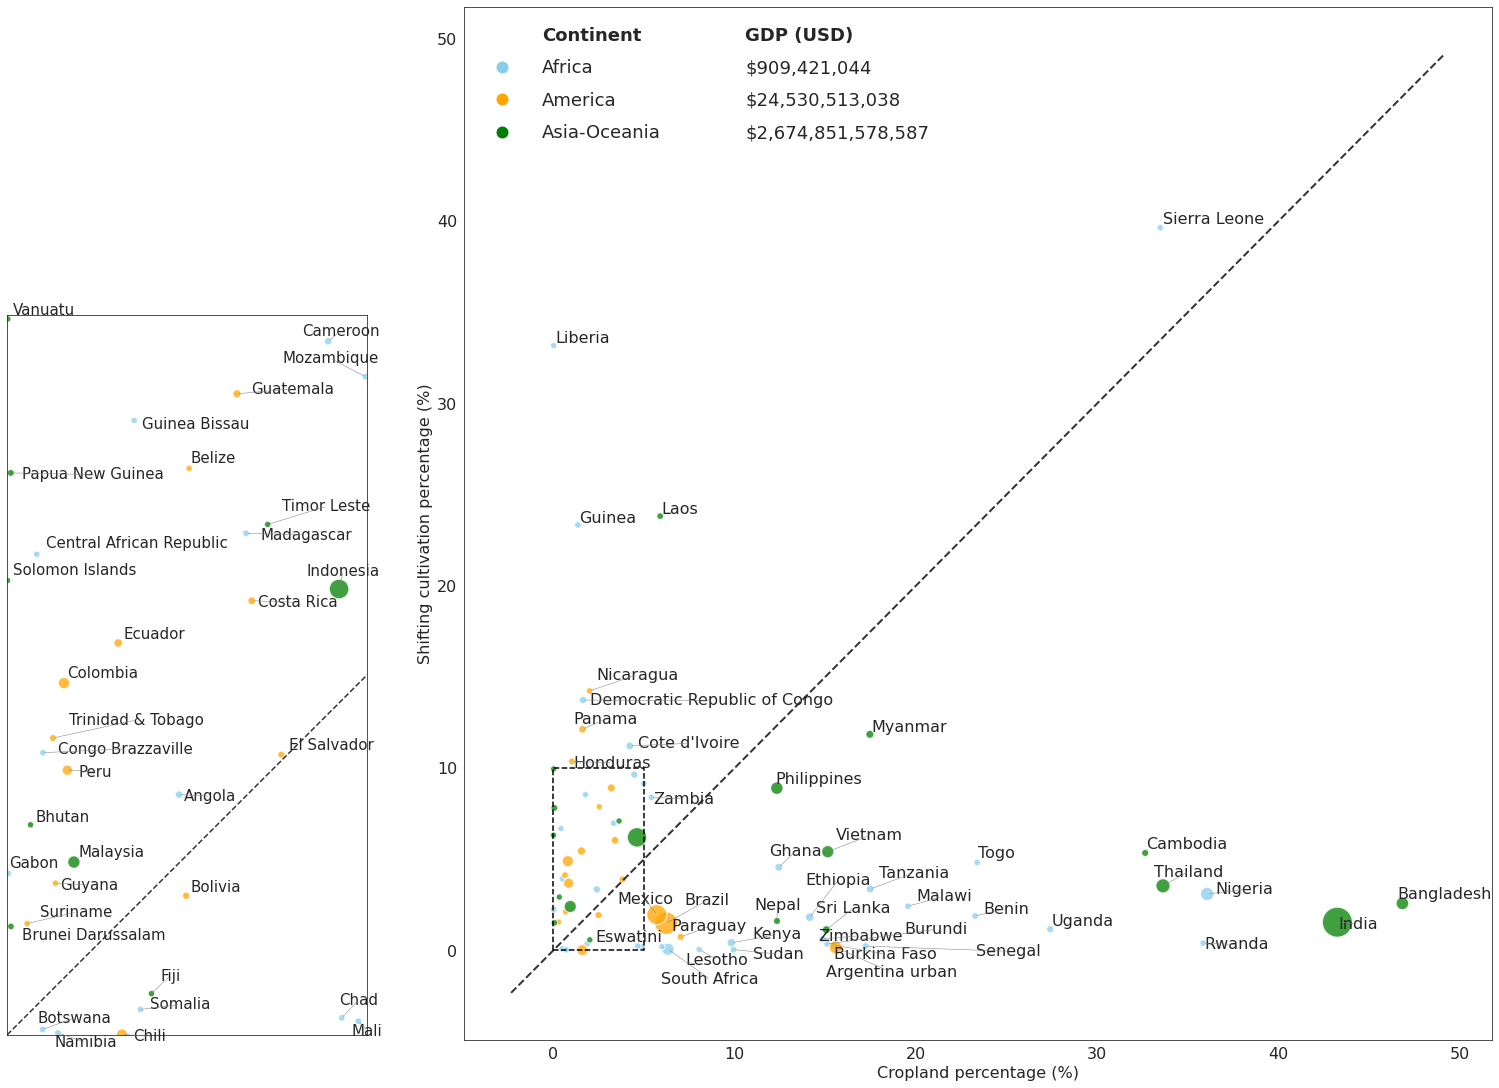

In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from adjustText import adjust_text
import pandas as pd

# ---------------------------------------
# SETTINGS
# ---------------------------------------

size_scale = 1

zoom_xmin, zoom_xmax = 0, 5
zoom_ymin, zoom_ymax = 0, 10

# Adjust where inset appears (CHANGE THESE)
inset_x = -0.45
inset_y = 0
inset_width = 5
inset_height = 10

continent_colors = {
    "Africa": "skyblue",
    "America": "orange",
    "Asia-Oceania": "green"
}

# ---------------------------------------
# PREPARE ZOOM CONDITION
# ---------------------------------------

df["is_zoom"] = (
    (df["cropland_percentage"] <= zoom_xmax) &
    (df["sc_percentage"] <= zoom_ymax)
)

# ---------------------------------------
# MAIN FIGURE
# ---------------------------------------

fig, ax = plt.subplots(figsize=(15, 15),constrained_layout=True)

texts = []

# --- MAIN SCATTER ---
for cont, sub in df.groupby("continent"):
    sub = sub.sort_values("bubble_size_total", ascending=False)

    ax.scatter(
        sub["cropland_percentage"],
        sub["sc_percentage"],
        s=sub["bubble_size_total"] * size_scale,
        alpha=0.75,
        label=cont,
        color=continent_colors.get(cont, "gray"),
        edgecolor="white",
        linewidth=1.2
    )

    # LABEL ONLY NON-ZOOM POINTS
    for _, row in sub.iterrows():
        if not row["is_zoom"]:
            texts.append(
                ax.text(
                    row["cropland_percentage"],
                    row["sc_percentage"],
                    row["country"],
                    fontsize=16
                )
            )

# --- 1:1 diagonal ---
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
low = min(xmin, ymin)
high = max(xmax, ymax)
plt.plot([low, high], [low, high], linestyle="--", linewidth=2, color="black", alpha=0.8)

# --- Continent legend ---
continent_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=continent_colors.get(cont, "gray"),
        markeredgecolor="white",
        markersize=13,
        label=cont
    )
    for cont in sorted(df_1["continent"].unique())
]
from matplotlib.lines import Line2D

# --- GDP values ---
gdp_min = df["gdp"].min()
gdp_median = df["gdp"].median()
gdp_max = df["gdp"].max()

gdp_values = [gdp_min, gdp_median, gdp_max]

gdp_handles = [
    plt.scatter(
        [], [],
        s=value * size_scale,
        facecolors="none",
        edgecolors="black",
        linewidth=1.5
    )
    for value in gdp_values
]

gdp_labels = [f"${value:,.0f}" for value in gdp_values]


# --- Create Section Headers ---
continent_header = Line2D([], [], linestyle="none")
gdp_header = Line2D([], [], linestyle="none")


# --- Combine everything ---
combined_handles = (
    [continent_header] +
    continent_handles +
    [gdp_header] +
    gdp_handles
)

combined_labels = (
    ["Continent"] +
    [h.get_label() for h in continent_handles] +
    ["GDP (USD)"] +
    gdp_labels
)


legend = plt.legend(
    combined_handles,
    combined_labels,
    frameon=False,
    loc="upper left",
    fontsize=18,
    handletextpad=1.2,
    labelspacing=0.8,
    borderpad=0.6,
    ncol=2,                 # 🔥 makes GDP horizontal
    columnspacing=1.5
)

# Make section headers bold
for text in legend.get_texts():
    if text.get_text() in ["Continent", "GDP (USD)"]:
        text.set_weight("bold")

# plt.legend(
#     handles=continent_handles,
#     title="Continent",
#     title_fontsize=20,
#     fontsize=18,
#     frameon=False,
#     loc="upper left"
# )
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# ---------------------------------------
# ADJUST MAIN LABELS ONLY
# ---------------------------------------

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
    force_objects=(1.0, 1.0),  # stronger repulsion between text and points
    autoalign='xy',
    force_text=0.5,   # push/pull strength of text
    force_points=0.5, # repulsion from points
    expand_text=(1.2, 1.2),  # increase spacing around text
    expand_points=(1.2, 1.2),
    lim=1000,         # max number of iterations
    precision=0.1,    # finer adjustment
)

# ---------------------------------------
# ZOOM INSET
# ---------------------------------------

axins = inset_axes(
    ax,
    width=inset_width,
    height=inset_height,
    loc="lower left",
    bbox_to_anchor=(inset_x, inset_y, 1, 1),
    bbox_transform=ax.transAxes
)

text1 = []

# Scatter in inset
for cont, sub in df.groupby("continent"):
    sub_zoom = sub[sub["is_zoom"]]

    axins.scatter(
        sub_zoom["cropland_percentage"],
        sub_zoom["sc_percentage"],
        s=sub_zoom["bubble_size_total"] * size_scale,
        alpha=0.75,
        color=continent_colors.get(cont, "gray"),
        edgecolor="white",
        linewidth=1
    )

    # Labels ONLY for zoom points
    for _, row in sub_zoom.iterrows():
        text1.append(
                axins.annotate(
            row["country"],
            (row["cropland_percentage"], row["sc_percentage"]),
            fontsize=15
            )
            )

# ---------------------------------------
# ADJUST MAIN LABELS ONLY
# ---------------------------------------

adjust_text(
    text1,
    ax=axins,
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
    force_objects=(1.0, 1.0),  # stronger repulsion between text and points
    autoalign='xy',
    force_text=0.5,   # push/pull strength of text
    force_points=0.5, # repulsion from points
    expand_text=(1.1, 1.1),  # increase spacing around text
    expand_points=(1.1, 1.1),
    lim=1000,         # max number of iterations
    precision=0.1,    # finer adjustment
)

# Zoom limits
axins.set_xlim(zoom_xmin, zoom_xmax)
axins.set_ylim(zoom_ymin, zoom_ymax)
axins.plot([0, 5], [0, 5], linestyle="--", color="black", linewidth=1.5, alpha=0.8)


# Remove ticks for cleaner look
axins.set_xticks([])
axins.set_yticks([])

# ---------------------------------------
# DRAW ZOOM RECTANGLE + PARALLEL DASHED LINES
# ---------------------------------------

rect = plt.Rectangle(
    (zoom_xmin, zoom_ymin),
    zoom_xmax - zoom_xmin,
    zoom_ymax - zoom_ymin,
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    facecolor='none'
)

ax.add_patch(rect)

# # Connect inset to rectangle
# mark_inset(
#     ax,
#     axins,
#     loc1=2,
#     loc2=4,
#     fc="none",
#     ec="black",
#     linestyle="--"
# )

# ---------------------------------------
# FINAL FORMATTING
# ---------------------------------------

ax.set_xlabel("Cropland percentage (%)", fontsize=16)
ax.set_ylabel("Shifting cultivation percentage (%)", fontsize=16)

# #--- Save figure ---
# plt.savefig(
#     '/mnt/warehouse/shifting_cultivation/111_result/figure/GDP/total_gdp_c_sc_0323.png',
#     dpi=600,
#     bbox_inches='tight'
# )
 
#fig.subplots_adjust(left=0.12, right=0.95, bottom=0.12, top=0.95)
plt.show()

In [33]:
from scipy.stats import spearmanr, pearsonr

# Pearson correlation
corr, p = pearsonr(df_ratio["sc_c_ratio"], df_ratio["GDP per capita (current US$)"])
print("Pearson correlation:", corr)
print("p-value:", p)

# Optional: Spearman correlation
corr_s, p_s = spearmanr(df_ratio["sc_c_ratio"], df_ratio["GDP per capita (current US$)"])
print("Spearman correlation:", corr_s)
print("p-value:", p_s)

Pearson correlation: -0.15490606168652465
p-value: 0.36700527884910783
Spearman correlation: 0.0640926640926641
p-value: 0.710364536093261
